In [1]:
from pathlib import Path
import sys

REPO_ROOT = Path().resolve().parents[1]
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from cuthberto_carlos.data import download_data, to_jax_data
MAX_GOALS = 8

pd_data, _, _, _ = download_data(max_goals=MAX_GOALS)

# Must match the filtering and re-indexing in model_fact_smc.py
train_data = pd_data[
    (pd_data['date'] > pd.to_datetime("2020-01-01"))
    & (pd_data['date'] < pd.to_datetime("2026-06-11"))
].copy()

# Re-index team IDs to contiguous 0..N-1 (same as model_fact_smc.py)
teams_in_subset = sorted(set(train_data['home_team_id']) | set(train_data['away_team_id']))
old_to_new_id = {old: new for new, old in enumerate(teams_in_subset)}
train_data['home_team_id'] = train_data['home_team_id'].map(old_to_new_id)
train_data['away_team_id'] = train_data['away_team_id'].map(old_to_new_id)

teams_id_to_name_dict = {}
for _, row in train_data.iterrows():
    teams_id_to_name_dict[int(row['home_team_id'])] = row['home_team']
    teams_id_to_name_dict[int(row['away_team_id'])] = row['away_team']

num_teams = len(teams_id_to_name_dict)
print(f"Number of teams: {num_teams}")

Number of teams: 262


# Distribution Diagnostics

In [3]:
output_path = REPO_ROOT / "scripts" / "smc" / "output" / "fact_smc_filter_latest.npz"
latest_filter = np.load(output_path)['particles']  # Store the array, not the shape
latest_filter.shape  # Display the shape

(319, 10000, 2)

In [4]:
# Load weights and compute weighted means for all teams
log_weights = np.load(output_path)['log_weights']  # (F, P)
log_normalizing_constant = np.load(output_path)['log_normalizing_constant']
N = latest_filter.shape[1]

print(f"\n{'='*60}")
print(f"Factorial SMC Filter Summary")
print(f"{'='*60}")
print(f"Particles per factor:      {N}")
print(f"Number of teams (factors): {num_teams}")
print(f"Number of matches:         {len(train_data)}")
print(f"Log normalizing constant:  {float(log_normalizing_constant):.2f}")
print(f"Training period:           {train_data['date'].min().date()} to {train_data['date'].max().date()}")

# Normalize weights per factor (handle NaN by setting uniform weights)
weights = np.exp(log_weights - log_weights.max(axis=-1, keepdims=True))
weights = weights / weights.sum(axis=-1, keepdims=True)

# Weighted means: (F, 2) — [attack, defence]
weighted_means = np.sum(latest_filter * weights[..., None], axis=1)

# Particle summary stats
valid_mask = ~np.isnan(weighted_means[:, 0])
print(f"\n--- Particle Summary ---")
print(f"Teams with valid estimates: {valid_mask.sum()} / {num_teams}")
print(f"Attack range: [{weighted_means[valid_mask, 0].min():.3f}, {weighted_means[valid_mask, 0].max():.3f}]")
print(f"Defence range: [{weighted_means[valid_mask, 1].min():.3f}, {weighted_means[valid_mask, 1].max():.3f}]")
print(f"Attack mean: {weighted_means[valid_mask, 0].mean():.3f}, std: {weighted_means[valid_mask, 0].std():.3f}")
print(f"Defence mean: {weighted_means[valid_mask, 1].mean():.3f}, std: {weighted_means[valid_mask, 1].std():.3f}")

# Top 5 by attack (higher = better)
print(f"\n--- Top 5 Teams by Attack (higher = better) ---")
attack_means = weighted_means[:, 0]
valid = ~np.isnan(attack_means)
top_attack = np.argsort(attack_means[valid])[-5:][::-1]
valid_indices = np.where(valid)[0]
for idx in top_attack:
    team_idx = int(valid_indices[idx])
    name = teams_id_to_name_dict.get(team_idx, f"Team {team_idx}")
    print(f"  {name}: attack={attack_means[team_idx]:.3f}, defence={weighted_means[team_idx, 1]:.3f}")

# Top 5 by defence (higher = better, reduces opponent scoring)
print(f"\n--- Top 5 Teams by Defence (higher = better) ---")
defence_means = weighted_means[:, 1]
valid_def = ~np.isnan(defence_means)
top_defence = np.argsort(defence_means[valid_def])[-5:][::-1]
valid_def_indices = np.where(valid_def)[0]
for idx in top_defence:
    team_idx = int(valid_def_indices[idx])
    name = teams_id_to_name_dict.get(team_idx, f"Team {team_idx}")
    print(f"  {name}: attack={weighted_means[team_idx, 0]:.3f}, defence={defence_means[team_idx]:.3f}")


Factorial SMC Filter Summary
Particles per factor:      10000
Number of teams (factors): 262
Number of matches:         6001
Log normalizing constant:  nan
Training period:           2020-01-07 to 2026-06-10

--- Particle Summary ---
Teams with valid estimates: 213 / 262
Attack range: [-1.306, 0.954]
Defence range: [-1.257, 1.080]
Attack mean: -0.216, std: 0.458
Defence mean: 0.087, std: 0.487

--- Top 5 Teams by Attack (higher = better) ---
  Team 311: attack=0.954, defence=-0.270
  Sweden: attack=0.933, defence=0.503
  Bolivia: attack=0.886, defence=0.811
  Cambodia: attack=0.865, defence=0.061
  Sri Lanka: attack=0.674, defence=0.470

--- Top 5 Teams by Defence (higher = better) ---
  Austria: attack=0.457, defence=1.080
  American Samoa: attack=0.213, defence=1.079
  Marshall Islands: attack=-0.237, defence=0.993
  Mali: attack=-0.175, defence=0.974
  Puerto Rico: attack=0.324, defence=0.925


In [48]:
TEAMS = ["France", "Germany", "Italy", "Spain", "Argentina", "Brazil", "Netherlands", "Belgium"]
teams_name_to_id_dict = {v: k for k, v in teams_id_to_name_dict.items()}
team_ids = [teams_name_to_id_dict[name] for name in TEAMS]

print(f"Team IDs for {TEAMS}: {team_ids}")

selected_particles = latest_filter[team_ids, :, :]  # Shape: (8, P, 2)
N = selected_particles.shape[1]

# Create DataFrame for pairplot: columns are "Team Attack" and "Team Defense"
data_dict = {}
for i, team in enumerate(TEAMS):
    data_dict[f"{team} Attack"] = selected_particles[i, :, 0]
    data_dict[f"{team} Defense"] = selected_particles[i, :, 1]

df_particles = pd.DataFrame(data_dict)

print(f"Particles shape: {latest_filter.shape}")
print(f"Selected particles shape: {selected_particles.shape}")
print(f"DataFrame shape: {df_particles.shape}")

Team IDs for ['France', 'Germany', 'Italy', 'Spain', 'Argentina', 'Brazil', 'Netherlands', 'Belgium']: [77, 84, 112, 213, 9, 32, 159, 22]
Particles shape: (319, 10000, 2)
Selected particles shape: (8, 10000, 2)
DataFrame shape: (10000, 16)


In [49]:
df_particles

,France Attack,France Defense,Germany Attack,Germany Defense,Italy Attack,Italy Defense,Spain Attack,Spain Defense,Argentina Attack,Argentina Defense,Brazil Attack,Brazil Defense,Netherlands Attack,Netherlands Defense,Belgium Attack,Belgium Defense
0,0.093185,-0.358227,-0.416023,0.249688,-0.799155,-1.323265,-0.917107,0.623002,0.213788,0.328697,-0.618074,0.275547,-1.415680,-1.448555,-1.953497,-0.409359
1,-1.234058,-0.592469,-0.146877,-0.319939,-0.376070,-1.433197,-0.348865,1.290787,0.177500,-0.493003,-0.001258,-1.185967,-1.162388,1.128404,-1.387362,0.657719
2,-0.793167,-0.670829,0.584931,0.888254,-0.865162,-1.155593,-0.394520,0.111745,0.503038,0.369324,1.716505,0.830892,-0.567966,1.526274,0.630387,-0.416315
3,-1.362646,-0.906177,0.760052,0.053355,1.012490,0.002414,-0.759553,-1.284914,-1.152790,0.493563,0.272239,0.808966,-0.255679,1.491473,-1.258193,-0.347233
4,-0.419828,-0.614318,-0.799592,2.689194,0.734942,-0.204829,-0.715521,0.116765,-1.270695,0.441406,0.110138,0.693589,0.231377,0.807123,0.017067,0.685807
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,-0.127831,-0.312433,0.318338,1.038095,-0.831053,0.254802,-0.079922,0.662763,0.617315,-0.093481,-0.673702,-1.602572,0.023882,0.770456,-1.045572,-0.241346
9996,0.774027,-0.935633,-2.009837,1.824988,-0.383010,0.395046,-1.043636,1.129381,-0.904002,-0.250818,1.123643,0.403319,0.827870,0.333839,-0.860713,-0.084652
9997,-0.502830,-1.326889,-0.935547,1.735416,0.489907,1.332857,-0.582850,0.925208,-0.532883,-0.413646,-0.513526,0.704090,0.003996,0.015380,0.094638,-0.566286
9998,1.609419,-0.751788,-1.470738,0.776624,0.102810,1.834635,0.072703,1.275794,1.206848,-0.244108,1.027146,0.365567,0.009270,2.343174,2.654451,0.092831


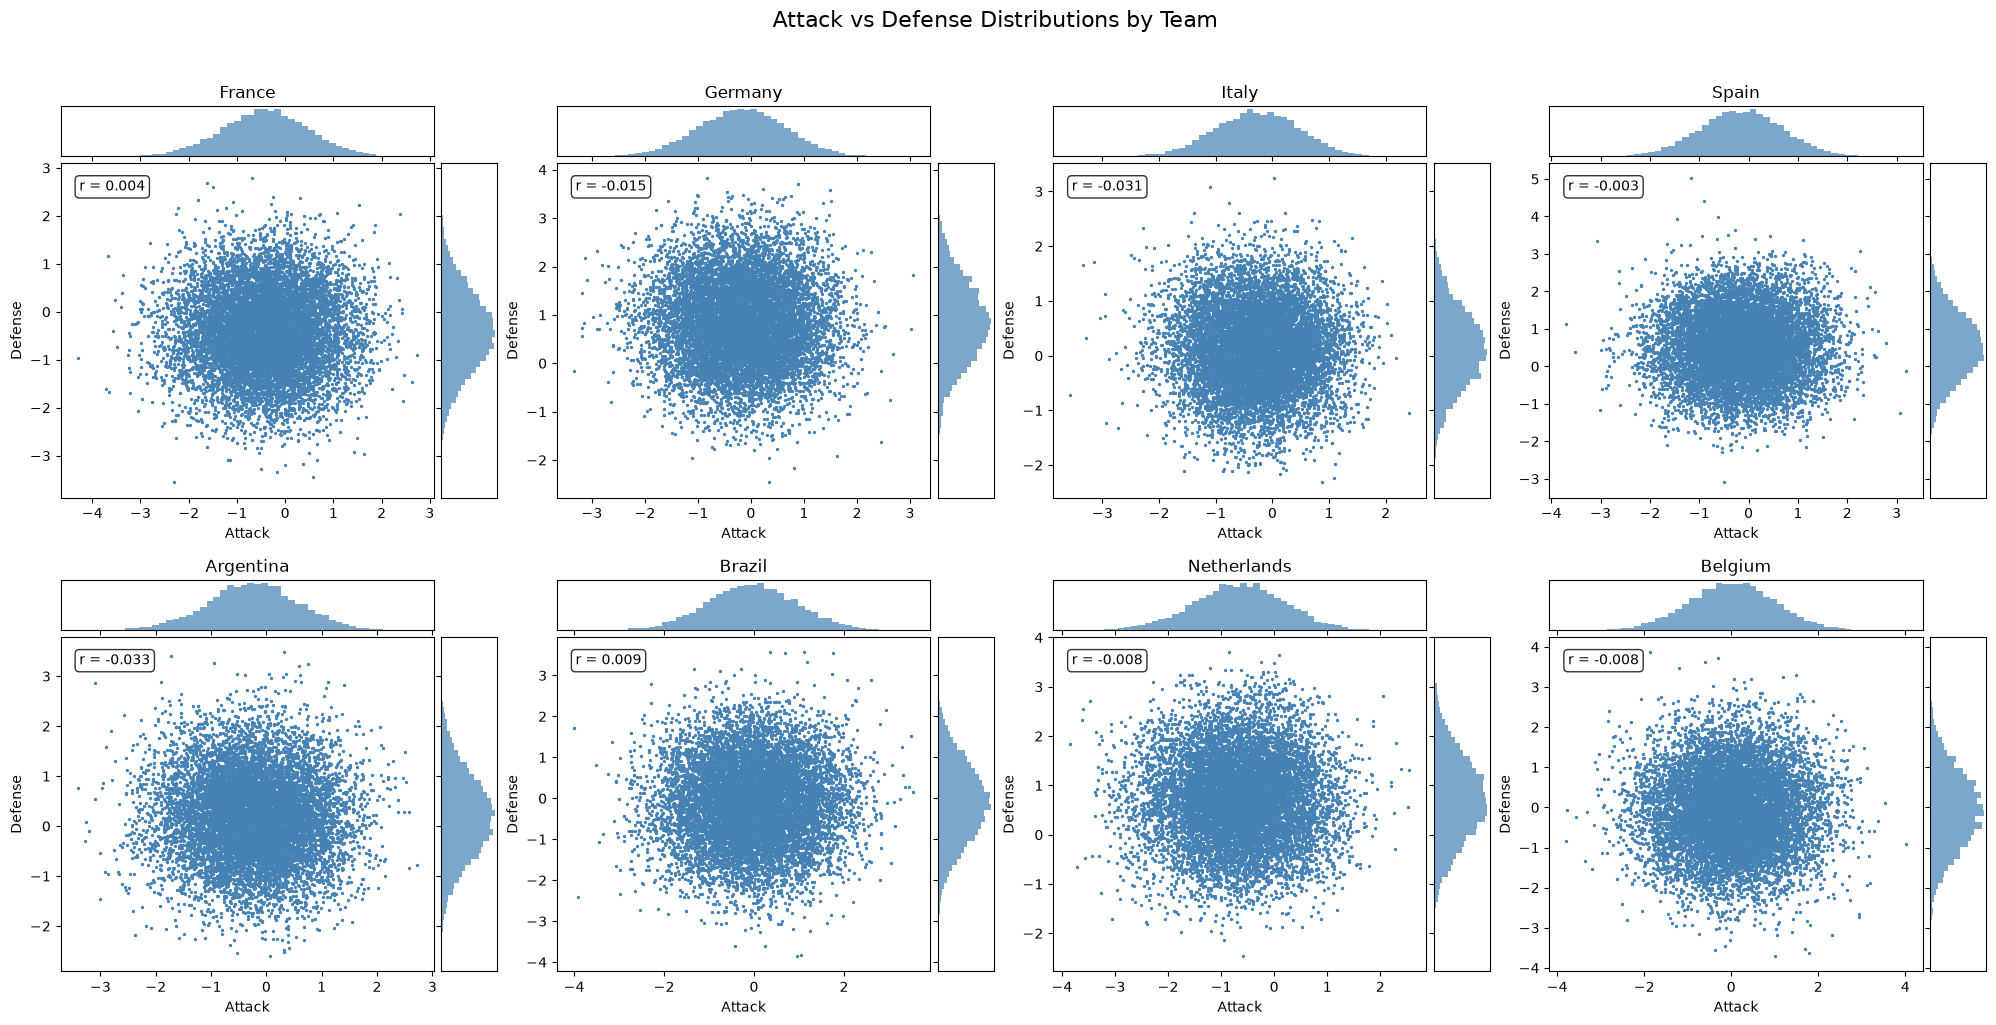

In [50]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, team in enumerate(TEAMS):
    ax = axes[idx]
    
    attack = selected_particles[idx, :, 0]
    defense = selected_particles[idx, :, 1]
    
    # Mask out NaN values
    valid = ~(np.isnan(attack) | np.isnan(defense))
    attack_valid = attack[valid]
    defense_valid = defense[valid]
    
    # Main scatter plot
    ax.scatter(attack_valid, defense_valid, alpha=1, s=2, color='steelblue')
    
    # Add marginal histograms on top and right
    ax_histx = ax.inset_axes([0, 1.02, 1, 0.15], sharex=ax)
    ax_histy = ax.inset_axes([1.02, 0, 0.15, 1], sharey=ax)
    
    ax_histx.hist(attack_valid, bins=50, alpha=0.7, color='steelblue', edgecolor='none')
    ax_histy.hist(defense_valid, bins=50, alpha=0.7, color='steelblue', edgecolor='none', orientation='horizontal')
    
    ax_histx.tick_params(axis="x", labelbottom=False)
    ax_histy.tick_params(axis="y", labelleft=False)
    ax_histx.set_yticks([])
    ax_histy.set_xticks([])
    
    # Labels and title
    ax.set_xlabel('Attack')
    ax.set_ylabel('Defense')
    ax.set_title(f'{team}')
    
    # Add correlation coefficient
    corr = np.corrcoef(attack_valid, defense_valid)[0, 1]
    ax.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax.transAxes, 
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Attack vs Defense Distributions by Team', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()